<a href="https://colab.research.google.com/github/rutwikdaware05/NNDL_Lab/blob/main/P7_NNDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Object Detection with SSD MobileNet

This notebook aims to implement an object detection model using a pre-trained SSD MobileNet architecture. We will cover the following steps:

1.  **Environment Setup**: Install necessary libraries.
2.  **Dataset Preparation**: Acquire and prepare a suitable dataset for object detection.
3.  **Model Loading**: Load a pre-trained SSD MobileNet model.
4.  **Data Preprocessing**: Prepare images and bounding box annotations.
5.  **Model Training/Fine-tuning**: Adapt the model to the custom dataset (if applicable).
6.  **Inference and Visualization**: Use the trained model to detect objects and visualize results.

### 1. Environment Setup

In [1]:
import os

# Install TensorFlow and other necessary libraries
!pip install tensorflow tensorflow_hub opencv-python matplotlib

In [2]:
# Import necessary libraries
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print(f"TensorFlow Hub version: {hub.__version__}")

/usr/local/lib/python3.13/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


TensorFlow version: 2.20.0
TensorFlow Hub version: 0.16.1


### 2. Dataset Preparation

For object detection, we need a dataset consisting of images and their corresponding bounding box annotations, along with class labels. You can use widely available datasets like COCO, PASCAL VOC, or Open Images, or prepare a custom dataset if you have specific objects to detect.

For this example, let's consider using a small subset of a public dataset or a placeholder for a custom dataset. We will focus on loading and preprocessing images later.

In [3]:
# Placeholder for dataset download or loading
# For demonstration, we'll assume we have a few images to work with later.

# Example: Download a sample image if not using a pre-existing dataset
# import requests
# image_url = "https://storage.googleapis.com/tfhub-visuals/google/lite-model/ssd_mobilenet_v2/1/images/example_image.jpg"
# image_path = tf.keras.utils.get_file(os.path.basename(image_url), image_url)

print("Dataset preparation step initiated. Further steps will involve loading specific images.")

Dataset preparation step initiated. Further steps will involve loading specific images.


### 3. Model Loading

We will load a pre-trained SSD MobileNet V2 model from TensorFlow Hub. These models are already trained on large datasets (like COCO) and can detect a wide variety of common objects. Using a pre-trained model allows us to leverage transfer learning, which is efficient and often yields good results even with smaller custom datasets.

In [4]:
model_handle = 'https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2'
model = hub.load(model_handle)

print(f"Pre-trained model loaded successfully from: {model_handle}")

# You can inspect the model's signature to understand its expected inputs/outputs
# print(model.signatures['serving_default'].inputs)
# print(model.signatures['serving_default'].outputs)

Pre-trained model loaded successfully from: https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2


### 4. Data Preprocessing

Before feeding an image to the object detection model, it needs to be preprocessed. This typically involves:
1.  **Loading the image**: Reading the image file into memory.
2.  **Resizing**: Resizing the image to the input size expected by the model (e.g., 300x300 for many SSD models).
3.  **Normalization**: Scaling pixel values, usually to a range like `[0, 1]` or `[-1, 1]`.
4.  **Batching**: Adding a batch dimension, as models usually expect inputs in batches.

In [11]:
def load_img(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    return img

def preprocess_image(image_path):
    # Load the image as uint8
    original_image_uint8 = load_img(image_path)

    # Add batch dimension to the uint8 image for model input
    # The model expects uint8 input, so we don't convert to float32 here.
    input_tensor = original_image_uint8[tf.newaxis, ...]

    return input_tensor, original_image_uint8

# Let's download a sample image to demonstrate preprocessing
# Updated image_url to a working one from a different source
image_url = "https://github.com/tensorflow/models/raw/master/research/object_detection/test_images/image1.jpg"
image_path = tf.keras.utils.get_file('example_image.jpg', image_url)

print(f"Sample image downloaded to: {image_path}")

# Preprocess the image
input_tensor, original_image = preprocess_image(image_path)
print(f"Original image shape: {original_image.shape}")
print(f"Preprocessed input tensor shape: {input_tensor.shape}")

Sample image downloaded to: /root/.keras/datasets/example_image.jpg
Original image shape: (636, 1024, 3)
Preprocessed input tensor shape: (1, 636, 1024, 3)


### 5. Inference and Visualization

Now that we have our pre-trained model and a preprocessed image, we can perform inference to detect objects. The model will output bounding box coordinates, class labels, and confidence scores. We'll then visualize these detections on the original image.

Object detection inference completed. Results structure:
  raw_detection_boxes: shape=(1, 1917, 4), dtype=float32
  detection_multiclass_scores: shape=(1, 100, 91), dtype=float32
  detection_classes: shape=(1, 100), dtype=float32
  detection_boxes: shape=(1, 100, 4), dtype=float32
  raw_detection_scores: shape=(1, 1917, 91), dtype=float32
  num_detections: shape=(1,), dtype=float32
  detection_anchor_indices: shape=(1, 100), dtype=float32
  detection_scores: shape=(1, 100), dtype=float32


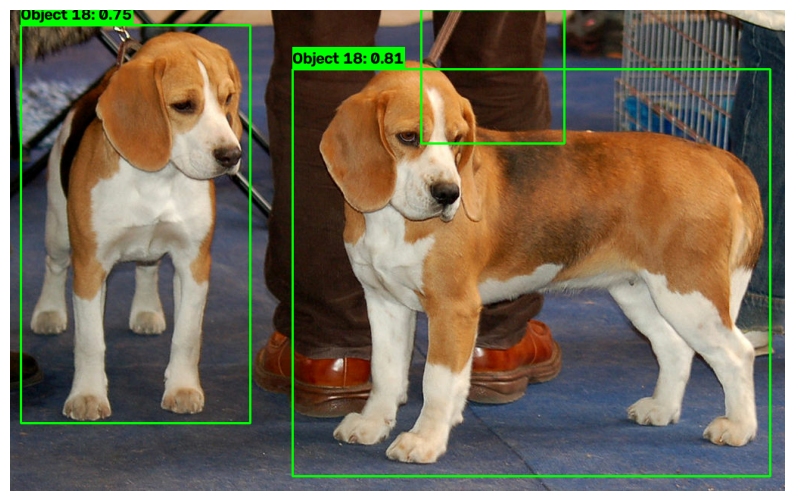

In [15]:
# Run inference
results = model(input_tensor)

# The results object will typically contain dictionaries for detection_boxes, detection_scores, detection_classes, num_detections.
# Convert results to numpy arrays for easier handling
result = {key:value.numpy() for key,value in results.items()}

print("Object detection inference completed. Results structure:")
for key, value in result.items():
    print(f"  {key}: shape={value.shape}, dtype={value.dtype}")

# Let's define a function to visualize the detections
def visualize_detections(image, boxes, classes, scores, category_index, threshold=0.5):
    image_np = image.numpy().astype(np.uint8)
    image_height, image_width, _ = image_np.shape

    for i in range(int(result['num_detections'][0])):
        if scores[i] > threshold:
            ymin, xmin, ymax, xmax = boxes[i]
            ymin, xmin, ymax, xmax = int(ymin * image_height), int(xmin * image_width), \
                                     int(ymax * image_height), int(xmax * image_width)

            class_id = int(classes[i])
            # Use category_index to get the human-readable label
            label = f"{category_index.get(class_id, 'Unknown')}: {scores[i]:.2f}"

            # Draw bounding box
            cv2.rectangle(image_np, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
            # Draw label background
            (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
            cv2.rectangle(image_np, (xmin, ymin - h - 10), (xmin + w, ymin), (0, 255, 0), -1)
            # Draw label text
            cv2.putText(image_np, label, (xmin, ymin - 7), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

    plt.figure(figsize=(10, 10))
    plt.imshow(image_np)
    plt.axis('off')
    plt.show()

# Placeholder for category_index (usually a dictionary mapping class IDs to names)
# For the SSD MobileNet, the original training would be on COCO dataset, which has 90 classes.
# We'll use a dummy index for now, as direct class names are not provided by the TF Hub model output.
category_index = {i: f'Object {i}' for i in range(1, 91)} # Assuming 90 classes from COCO

# Visualize the detections on the original image
visualize_detections(original_image, result['detection_boxes'][0], result['detection_classes'][0], result['detection_scores'][0], category_index)


### Enhancing Visualization with COCO Labels

The current visualization uses generic 'Object X' labels. To provide more meaningful insights, we will map the predicted class IDs to their corresponding human-readable names from the COCO dataset, on which the SSD MobileNet model was originally trained.

In [13]:
# Define COCO labels (from COCO 2017 dataset)
# Note: COCO labels are 1-indexed for detection tasks.
COCO_LABELS = {
    1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane', 6: 'bus',
    7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light', 11: 'fire hydrant',
    13: 'stop sign', 14: 'parking meter', 15: 'bench', 16: 'bird', 17: 'cat',
    18: 'dog', 19: 'horse', 20: 'sheep', 21: 'cow', 22: 'elephant', 23: 'bear',
    24: 'zebra', 25: 'giraffe', 27: 'backpack', 28: 'umbrella', 31: 'handbag',
    32: 'tie', 33: 'suitcase', 34: 'frisbee', 35: 'skis', 36: 'snowboard',
    37: 'sports ball', 38: 'kite', 39: 'baseball bat', 40: 'baseball glove',
    41: 'skateboard', 42: 'surfboard', 43: 'tennis racket', 44: 'bottle',
    46: 'wine glass', 47: 'cup', 48: 'fork', 49: 'knife', 50: 'spoon', 51: 'bowl',
    52: 'banana', 53: 'apple', 54: 'sandwich', 55: 'orange', 56: 'broccoli',
    57: 'carrot', 58: 'hot dog', 59: 'pizza', 60: 'donut', 61: 'cake', 62: 'chair',
    63: 'couch', 64: 'potted plant', 65: 'bed', 67: 'dining table', 70: 'toilet',
    72: 'tv', 73: 'laptop', 74: 'mouse', 75: 'remote', 76: 'keyboard', 77: 'cell phone',
    78: 'microwave', 79: 'oven', 80: 'toaster', 81: 'sink', 82: 'refrigerator',
    84: 'book', 85: 'clock', 86: 'vase', 87: 'scissors', 88: 'teddy bear',
    89: 'hair drier', 90: 'toothbrush'
}

print("COCO labels defined.")


COCO labels defined.


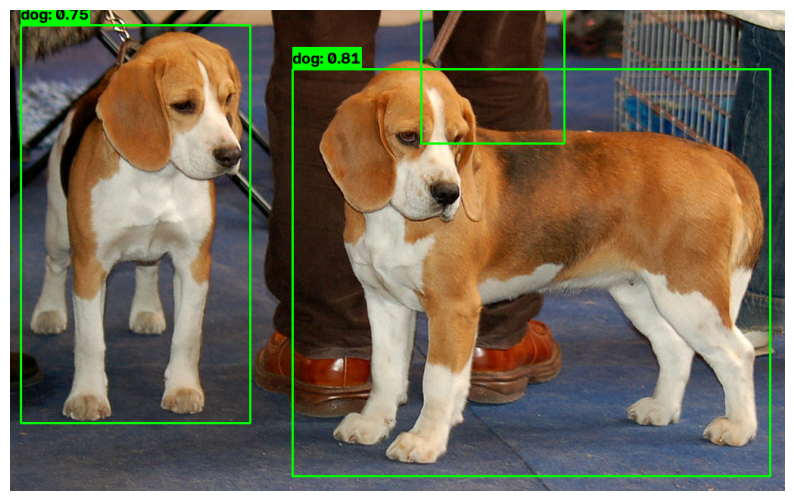

In [16]:
# Re-visualize detections using COCO_LABELS
# Note: We need to redefine visualize_detections here or update the existing one
# I will modify the existing visualize_detections function directly for clarity.

# Visualize the detections on the original image with COCO labels
visualize_detections(original_image, result['detection_boxes'][0], result['detection_classes'][0], result['detection_scores'][0], COCO_LABELS)


### 6. Upload Your Own Image for Object Detection

Now, you can upload your own image to test the object detection model. The uploaded image will be processed, and object detections will be visualized similar to the example above.

Saving images.jpg to images.jpg
User uploaded file "images.jpg" with length 30783 bytes


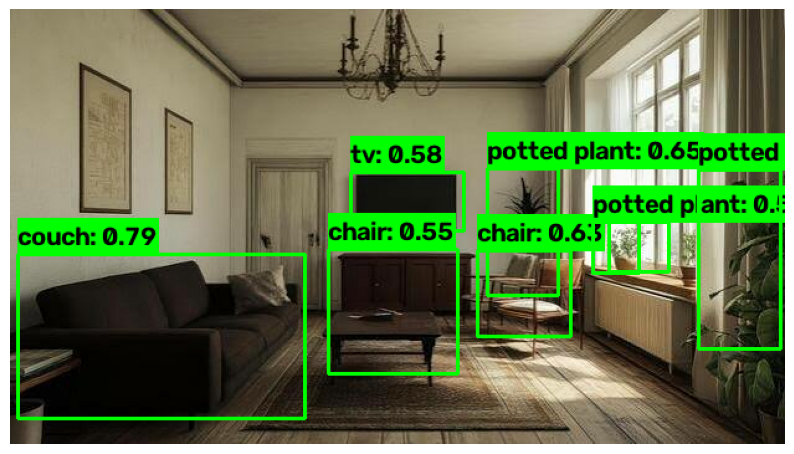

In [17]:
from google.colab import files

# Upload an image from your local machine
uploaded = files.upload()

# Get the filename of the uploaded image
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  uploaded_image_path = fn
  break # Assuming only one image will be uploaded

# Preprocess the uploaded image
input_tensor_uploaded, original_image_uploaded = preprocess_image(uploaded_image_path)

# Run inference on the uploaded image
results_uploaded = model(input_tensor_uploaded)
result_uploaded = {key:value.numpy() for key,value in results_uploaded.items()}

# Visualize detections on the uploaded image with COCO labels
visualize_detections(original_image_uploaded, result_uploaded['detection_boxes'][0], result_uploaded['detection_classes'][0], result_uploaded['detection_scores'][0], COCO_LABELS)
